In [11]:
import json
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
DATASET_PATH = "synthetic_outputs.jsonl"

### Loading the dataset

In [13]:
data = []
with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    for line in f.readlines():
        data.append(json.loads(line))

df = pd.DataFrame(data)
df.head()

,item_id,category,prompt_configuration,system_prompt,user_prompt,model_a,model_b,source_file,source_dataset,tags
0,spoken_45N11LAJ,f,advisor_casual,\n# ROLE\nYou are a helpful language learning ...,Voici la transcription d'une conversation que ...,"{'model_name': 'openai/gpt-5.4-mini', 'llm_res...",{'model_name': 'google/gemini-3-flash-preview'...,../data/wif_goteborg/transcripts/45N11LAJ.cha,spoken,NaN
1,spoken_45N11LAJ,f,teacher_casual,\n# ROLE\nYou are a helpful language learning ...,Voici la transcription d'une conversation que ...,"{'model_name': 'openai/gpt-5.4-mini', 'llm_res...",{'model_name': 'google/gemini-3-flash-preview'...,../data/wif_goteborg/transcripts/45N11LAJ.cha,spoken,NaN
2,spoken_45N11LAJ,f,original,\n# ROLE\nYou are a helpful language learning ...,Voici la transcription d'une conversation que ...,"{'model_name': 'openai/gpt-5.4-mini', 'llm_res...",{'model_name': 'google/gemini-3-flash-preview'...,../data/wif_goteborg/transcripts/45N11LAJ.cha,spoken,NaN
3,spoken_45N11LAJ,f,teacher_guided,\n# ROLE\nYou are a helpful language learning ...,Voici la transcription d'une conversation que ...,"{'model_name': 'openai/gpt-5.4-mini', 'llm_res...",{'model_name': 'google/gemini-3-flash-preview'...,../data/wif_goteborg/transcripts/45N11LAJ.cha,spoken,NaN
4,spoken_45N11LAJ,f,advisor_guided,\n# ROLE\nYou are a helpful language learning ...,Voici la transcription d'une conversation que ...,"{'model_name': 'openai/gpt-5.4-mini', 'llm_res...",{'model_name': 'google/gemini-3-flash-preview'...,../data/wif_goteborg/transcripts/45N11LAJ.cha,spoken,NaN


### Visualize the dataset

#### Model counts

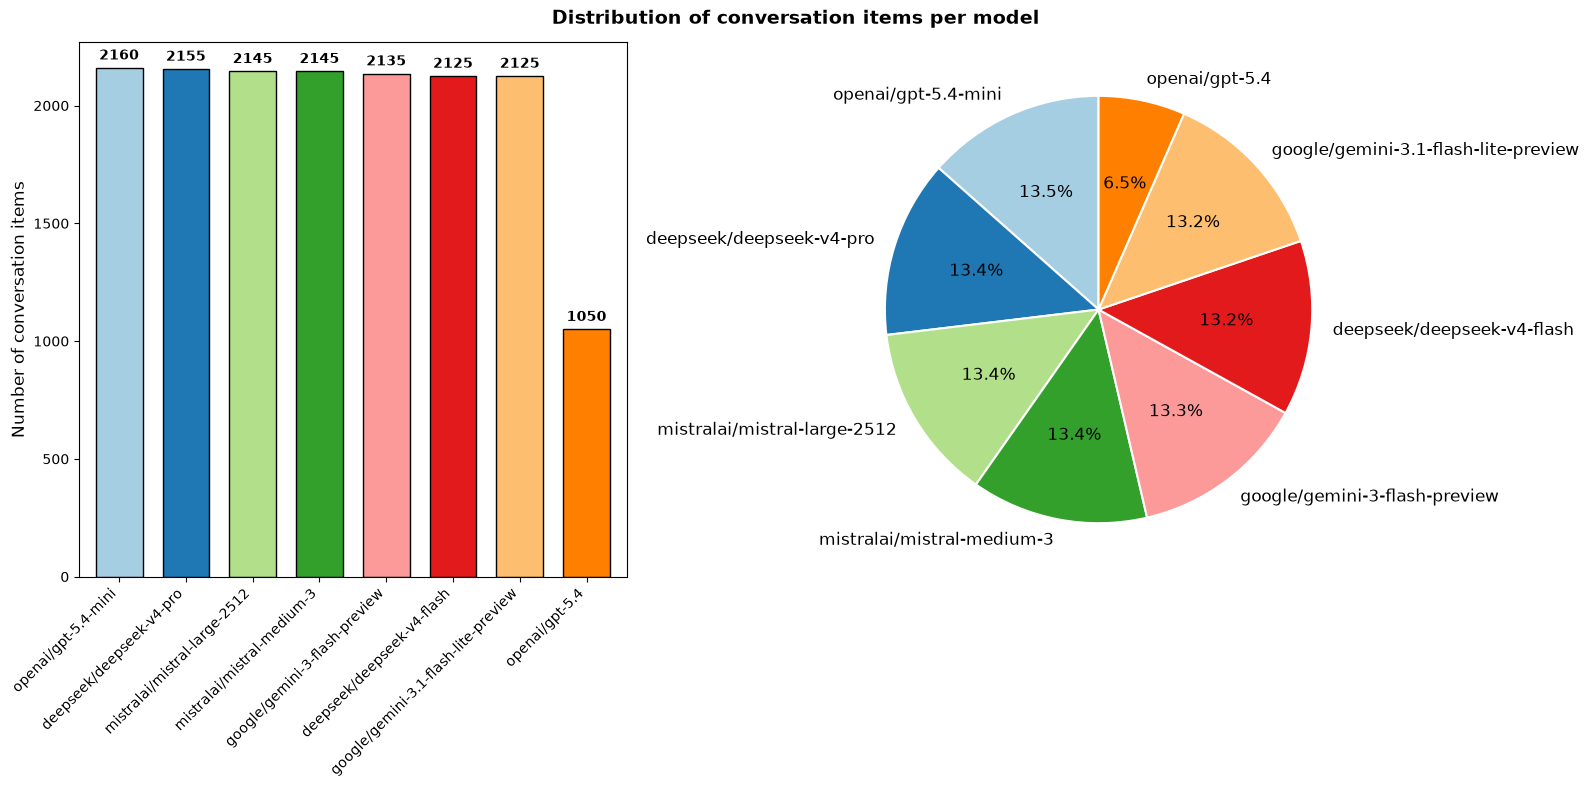

In [14]:
# Count each model's occurrences in the dataset

counts_a = df['model_a'].apply(lambda x: x.get('model_name')).value_counts()
counts_b = df['model_b'].apply(lambda x: x.get('model_name')).value_counts()

model_counts = counts_a.add(counts_b, fill_value=0).astype(int).sort_values(ascending=False)

# Plot the resulting charts

colours = plt.cm.Paired(range(len(model_counts)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

model_counts.plot.bar(ax=ax1, color=colours, edgecolor='black', width=0.7)

ax1.set_xlabel('', fontsize=12)
ax1.set_ylabel('Number of conversation items', fontsize=12)
ax1.set_xticklabels(model_counts.index, rotation=45, ha='right', fontsize=10)

for i, v in enumerate(model_counts):
    ax1.text(i, v + max(model_counts) * 0.01, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

model_counts.plot.pie(ax=ax2, autopct='%1.1f%%', startangle=90, colors=colours, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}, textprops={'fontsize': 12})

ax2.set_ylabel('')

fig.suptitle("Distribution of conversation items per model", fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

#### Completion token count

In [15]:
tokens = {model: 0 for model in df["model_a"].apply(lambda x: x.get("model_name")).unique()}

for idx, row in df.iterrows():
    model_a = row["model_a"].get("model_name")
    model_b = row["model_b"].get("model_name")
    
    usage_a = row["model_a"]["llm_usage"]
    usage_b = row["model_b"]["llm_usage"]
    
    if usage_a is not None:
        tokens[model_a] += usage_a.get("completion_tokens", 0)
    
    if usage_b is not None:
        tokens[model_b] += usage_b.get("completion_tokens", 0)

In [16]:
pd.options.display.float_format = '{: .0f}'.format
out = pd.DataFrame(list(tokens.items()), columns=["Model", "Completion Tokens"]).sort_values(by="Completion Tokens", ascending=False)

avg_tokens_per_completion = out["Completion Tokens"] / model_counts[out["Model"]].values
out["Average Tokens per Completion"] = avg_tokens_per_completion

total_tokens = out["Completion Tokens"].sum()
out["Percentage"] = (out["Completion Tokens"] / total_tokens) * 100

min_tokens = out["Completion Tokens"].min()
out["Factor"] = out["Completion Tokens"] / min_tokens

out['Completion Tokens'] = out['Completion Tokens'].apply('{:,}'.format)
out['Average Tokens per Completion'] = out['Average Tokens per Completion'].apply('{:,.2f}'.format)
out['Percentage'] = out['Percentage'].apply(lambda x: f"{x:.1f} %")
out['Factor'] = out['Factor'].apply(lambda x: f"{x:.2f}")

print(out)

                                  Model Completion Tokens  \
7              deepseek/deepseek-v4-pro         4,249,437   
6          mistralai/mistral-large-2512         3,222,909   
1            deepseek/deepseek-v4-flash         2,969,075   
0                   openai/gpt-5.4-mini         1,908,353   
5                        openai/gpt-5.4         1,790,594   
3         google/gemini-3-flash-preview         1,591,362   
4  google/gemini-3.1-flash-lite-preview         1,449,642   
2            mistralai/mistral-medium-3         1,433,519   

  Average Tokens per Completion Percentage Factor  
7                      1,971.90     22.8 %   2.96  
6                      1,502.52     17.3 %   2.25  
1                      1,397.21     15.9 %   2.07  
0                        883.50     10.3 %   1.33  
5                      1,705.33      9.6 %   1.25  
3                        745.37      8.5 %   1.11  
4                        682.18      7.8 %   1.01  
2                        668.31   

Some of the models, mostly frontier ones (`deepseek/deepseek-v4-pro`, `mistralai/mistral-large-2512`, `deepseek/deepseek-v4-flash`, `openai/gpt-5.4`) consume much more output tokens than others (2- to 3-fold).

#### Analysis of prompt configurations

In [21]:
# Count output tokens per prompt configuration

out = df.copy()

COMPLETION_TOKENS = "completion_tokens"

out["output_a"] = out["model_a"].str["llm_usage"].str[COMPLETION_TOKENS].fillna(0)
out["output_b"] = out["model_b"].str["llm_usage"].str[COMPLETION_TOKENS].fillna(0)

out["total_output_tokens"] = out["output_a"] + out["output_b"]

avg_per_config = out.groupby("prompt_configuration")["total_output_tokens"].mean()

print(avg_per_config)

prompt_configuration
advisor_casual    2349
advisor_guided    2534
original          1903
teacher_casual    2330
teacher_guided    2489
Name: total_output_tokens, dtype: float64


#### Number of completions finished abnormally

In [47]:
out = df.copy()

counts = out["model_a"].str["llm_usage"].str["finish_reason"].fillna("stop")
print(counts.value_counts())

model_a
stop    8020
Name: count, dtype: int64
